# Introducción a Pandas y representación Grafica

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# 1. Introducción y Estructuras Básicas

## 1.1 Series
Una **Serie** en pandas es una estructura de datos **unidimensional**, similar a una columna de una hoja de cálculo o una matriz de una sola dimensión en otros lenguajes de programación.

In [3]:
# Diferentes formas de crear Series
serie_lista = pd.Series([1, 2, 3, 4, 5])
serie_dict = pd.Series({'a': 1, 'b': 2, 'c': 3})
serie_numpy = pd.Series(np.random.randn(5))

In [4]:
print("Serie desde lista:")
print(serie_lista)
print("\nSerie desde diccionario:")
print(serie_dict)
print("\nSerie desde array numpy:")
print(serie_numpy)

Serie desde lista:
0    1
1    2
2    3
3    4
4    5
dtype: int64

Serie desde diccionario:
a    1
b    2
c    3
dtype: int64

Serie desde array numpy:
0   -0.386541
1   -0.677933
2   -0.442177
3    1.184146
4    0.488622
dtype: float64


In [10]:
# Operaciones con Series
serie1 = pd.Series([1, 2, 3, 4])
serie2 = pd.Series([2, 4, 6, 8])

print("\nOperaciones con Series:")
print("Suma:\n", serie1 + serie2)
print("Multiplicación:\n", serie1 * serie2)
print("Raíz cuadrada:\n", np.sqrt(serie1))


Operaciones con Series:
Suma:
 0     3
1     6
2     9
3    12
dtype: int64
Multiplicación:
 0     2
1     8
2    18
3    32
dtype: int64
Raíz cuadrada:
 0    1.000000
1    1.414214
2    1.732051
3    2.000000
dtype: float64


## 1.2 DataFrames
Un **DataFrame** en pandas es una estructura de datos **bidimensional**, similar a una tabla en una base de datos o a una hoja de cálculo de Excel. Es una de las principales estructuras de datos en pandas y está diseñada para trabajar con datos etiquetados en filas y columnas.

In [11]:
# Diferentes formas de crear DataFrames

# Desde diccionario
df1 = pd.DataFrame({
    'nombre': ['Ana', 'Juan', 'María', 'Pedro', 'Luis'],
    'edad': [25, 30, 22, 28, 35],
    'ciudad': ['Madrid', 'Barcelona', 'Sevilla', 'Valencia', 'Bilbao'],
    'salario': [30000, 45000, 28000, 35000, 42000]
})

# Desde lista de diccionarios
datos_lista = [
    {'nombre': 'Ana', 'edad': 25},
    {'nombre': 'Juan', 'edad': 30},
    {'nombre': 'María', 'edad': 22}
]
df2 = pd.DataFrame(datos_lista)

# Desde array numpy
array_datos = np.random.rand(4, 3)
df3 = pd.DataFrame(array_datos, columns=['A', 'B', 'C'])

print("\nDataFrame desde diccionario:")
print(df1)
print("\nDataFrame desde lista de diccionarios:")
print(df2)
print("\nDataFrame desde array numpy:")
print(df3)


DataFrame desde diccionario:
  nombre  edad     ciudad  salario
0    Ana    25     Madrid    30000
1   Juan    30  Barcelona    45000
2  María    22    Sevilla    28000
3  Pedro    28   Valencia    35000
4   Luis    35     Bilbao    42000

DataFrame desde lista de diccionarios:
  nombre  edad
0    Ana    25
1   Juan    30
2  María    22

DataFrame desde array numpy:
          A         B         C
0  0.810210  0.051918  0.521478
1  0.477888  0.822764  0.564258
2  0.865647  0.664829  0.114817
3  0.036691  0.736731  0.031323


# 2. Exploración de datos

In [12]:
# Crear un DataFrame más complejo para ejemplos
np.random.seed(42)
df_ventas = pd.DataFrame({
    'fecha': pd.date_range(start='2023-01-01', periods=100, freq='D'),
    'producto': np.random.choice(['A', 'B', 'C', 'D'], size=100),
    'vendedor': np.random.choice(['Juan', 'María', 'Pedro', 'Ana'], size=100),
    'unidades': np.random.randint(1, 50, size=100),
    'precio_unitario': np.random.uniform(10, 100, size=100).round(2),
    'región': np.random.choice(['Norte', 'Sur', 'Este', 'Oeste'], size=100)
})
print(df_ventas)

        fecha producto vendedor  unidades  precio_unitario región
0  2023-01-01        C    Pedro        32            11.49   Este
1  2023-01-02        D    María        39            56.09    Sur
2  2023-01-03        A    María        49            30.38  Norte
3  2023-01-04        C      Ana        32            68.07  Oeste
4  2023-01-05        C    María         4            25.69  Norte
..        ...      ...      ...       ...              ...    ...
95 2023-04-06        B    María        16            72.73   Este
96 2023-04-07        B    María        29            73.22    Sur
97 2023-04-08        D      Ana         3            42.35  Oeste
98 2023-04-09        B     Juan        20            36.42    Sur
99 2023-04-10        A    Pedro        36            82.84    Sur

[100 rows x 6 columns]


In [13]:
# Calcular el total de ventas
df_ventas['total_venta'] = df_ventas['unidades'] * df_ventas['precio_unitario']
print(df_ventas)

        fecha producto vendedor  unidades  precio_unitario región  total_venta
0  2023-01-01        C    Pedro        32            11.49   Este       367.68
1  2023-01-02        D    María        39            56.09    Sur      2187.51
2  2023-01-03        A    María        49            30.38  Norte      1488.62
3  2023-01-04        C      Ana        32            68.07  Oeste      2178.24
4  2023-01-05        C    María         4            25.69  Norte       102.76
..        ...      ...      ...       ...              ...    ...          ...
95 2023-04-06        B    María        16            72.73   Este      1163.68
96 2023-04-07        B    María        29            73.22    Sur      2123.38
97 2023-04-08        D      Ana         3            42.35  Oeste       127.05
98 2023-04-09        B     Juan        20            36.42    Sur       728.40
99 2023-04-10        A    Pedro        36            82.84    Sur      2982.24

[100 rows x 7 columns]


## 2.1 Métodos de exploración

In [18]:
print("Información del DataFrame:")
print(df_ventas.info())

Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   fecha            100 non-null    datetime64[ns]
 1   producto         100 non-null    object        
 2   vendedor         100 non-null    object        
 3   unidades         100 non-null    int32         
 4   precio_unitario  100 non-null    float64       
 5   región           100 non-null    object        
 6   total_venta      100 non-null    float64       
dtypes: datetime64[ns](1), float64(2), int32(1), object(3)
memory usage: 5.2+ KB
None


In [17]:
print("Estadísticas descriptivas:")
print(df_ventas.describe())

Estadísticas descriptivas:
                     fecha    unidades  precio_unitario  total_venta
count                  100  100.000000       100.000000   100.000000
mean   2023-02-19 12:00:00   25.400000        57.669900  1511.493500
min    2023-01-01 00:00:00    1.000000        10.460000    10.830000
25%    2023-01-25 18:00:00   11.750000        33.705000   486.782500
50%    2023-02-19 12:00:00   28.000000        61.230000  1159.995000
75%    2023-03-16 06:00:00   37.000000        80.525000  2297.332500
max    2023-04-10 00:00:00   49.000000        99.100000  4780.930000
std                    NaN   14.760718        26.674979  1225.898739


In [19]:
print("Primeras 5 filas:")
print(df_ventas.head())

Primeras 5 filas:
       fecha producto vendedor  unidades  precio_unitario región  total_venta
0 2023-01-01        C    Pedro        32            11.49   Este       367.68
1 2023-01-02        D    María        39            56.09    Sur      2187.51
2 2023-01-03        A    María        49            30.38  Norte      1488.62
3 2023-01-04        C      Ana        32            68.07  Oeste      2178.24
4 2023-01-05        C    María         4            25.69  Norte       102.76


In [20]:
print("Últimas 5 filas:")
print(df_ventas.tail())

Últimas 5 filas:
        fecha producto vendedor  unidades  precio_unitario región  total_venta
95 2023-04-06        B    María        16            72.73   Este      1163.68
96 2023-04-07        B    María        29            73.22    Sur      2123.38
97 2023-04-08        D      Ana         3            42.35  Oeste       127.05
98 2023-04-09        B     Juan        20            36.42    Sur       728.40
99 2023-04-10        A    Pedro        36            82.84    Sur      2982.24


## 2.2 Selección y filtrado avanzado

In [21]:
# Selección por etiquetas
print("Selección de columnas específicas:")
print(df_ventas[['producto', 'unidades', 'total_venta']].head())

Selección de columnas específicas:
  producto  unidades  total_venta
0        C        32       367.68
1        D        39      2187.51
2        A        49      1488.62
3        C        32      2178.24
4        C         4       102.76


In [22]:
# Filtrado con múltiples condiciones
ventas_filtradas = df_ventas[
    (df_ventas['unidades'] > 30) & 
    (df_ventas['región'] == 'Norte')
]
print("\nVentas filtradas (unidades > 30 en región Norte):")
print(ventas_filtradas)


Ventas filtradas (unidades > 30 en región Norte):
        fecha producto vendedor  unidades  precio_unitario región  total_venta
2  2023-01-03        A    María        49            30.38  Norte      1488.62
8  2023-01-09        C    María        39            22.38  Norte       872.82
39 2023-02-09        C     Juan        39            59.39  Norte      2316.21
47 2023-02-17        C    Pedro        44            68.47  Norte      3012.68
50 2023-02-20        C    Pedro        32            61.15  Norte      1956.80
54 2023-02-24        C     Juan        49            31.96  Norte      1566.04
90 2023-04-01        D    Pedro        48            99.10  Norte      4756.80


In [23]:
# Filtrado usando query
ventas_query = df_ventas.query('unidades > 30 and región == "Norte"')
print("\nMismo filtrado usando query:")
print(ventas_query)


Mismo filtrado usando query:
        fecha producto vendedor  unidades  precio_unitario región  total_venta
2  2023-01-03        A    María        49            30.38  Norte      1488.62
8  2023-01-09        C    María        39            22.38  Norte       872.82
39 2023-02-09        C     Juan        39            59.39  Norte      2316.21
47 2023-02-17        C    Pedro        44            68.47  Norte      3012.68
50 2023-02-20        C    Pedro        32            61.15  Norte      1956.80
54 2023-02-24        C     Juan        49            31.96  Norte      1566.04
90 2023-04-01        D    Pedro        48            99.10  Norte      4756.80


# 3. Manipulación de datos

## 3.1 Manejo de valores faltantes

In [24]:
df_ventas_na = df_ventas.copy()
df_ventas_na.loc[np.random.choice(df_ventas.index, 10), 'unidades'] = np.nan
df_ventas_na.loc[np.random.choice(df_ventas.index, 10), 'precio_unitario'] = np.nan

In [26]:
print("Valores faltantes por columna:")
print(df_ventas_na.isna().sum())

Valores faltantes por columna:
fecha               0
producto            0
vendedor            0
unidades           10
precio_unitario    10
región              0
total_venta         0
dtype: int64


In [27]:
# Diferentes métodos de imputación
print("Rellenar con la media:")
print(df_ventas_na['unidades'].fillna(df_ventas_na['unidades'].mean()))

Rellenar con la media:
0     24.377778
1     39.000000
2     49.000000
3     32.000000
4      4.000000
        ...    
95    16.000000
96    29.000000
97     3.000000
98    20.000000
99    36.000000
Name: unidades, Length: 100, dtype: float64


In [34]:
print("Rellenar con el método forward fill:")
print(df_ventas_na['unidades'].ffill())

Rellenar con el método forward fill:
0      NaN
1     39.0
2     49.0
3     32.0
4      4.0
      ... 
95    16.0
96    29.0
97     3.0
98    20.0
99    36.0
Name: unidades, Length: 100, dtype: float64


## 3.2 Transformación de datos

In [37]:
# Crear nuevas columnas
df_ventas['mes'] = df_ventas['fecha'].dt.month
df_ventas['día_semana'] = df_ventas['fecha'].dt.day_name()
df_ventas

,fecha,producto,vendedor,unidades,precio_unitario,región,total_venta,mes,día_semana
0,2023-01-01,C,Pedro,32,11.49,Este,367.68,1,Sunday
1,2023-01-02,D,María,39,56.09,Sur,2187.51,1,Monday
2,2023-01-03,A,María,49,30.38,Norte,1488.62,1,Tuesday
3,2023-01-04,C,Ana,32,68.07,Oeste,2178.24,1,Wednesday
4,2023-01-05,C,María,4,25.69,Norte,102.76,1,Thursday
...,...,...,...,...,...,...,...,...,...
95,2023-04-06,B,María,16,72.73,Este,1163.68,4,Thursday
96,2023-04-07,B,María,29,73.22,Sur,2123.38,4,Friday
97,2023-04-08,D,Ana,3,42.35,Oeste,127.05,4,Saturday
98,2023-04-09,B,Juan,20,36.42,Sur,728.40,4,Sunday


In [40]:
# Aplicar funciones personalizadas
def categorizar_venta(total):
    if total < 500:
        return 'Baja'
    elif total < 1000:
        return 'Media'
    else:
        return 'Alta'

df_ventas['categoría_venta'] = df_ventas['total_venta'].apply(categorizar_venta)
df_ventas.head()

,fecha,producto,vendedor,unidades,precio_unitario,región,total_venta,mes,día_semana,categoría_venta
0,2023-01-01,C,Pedro,32,11.49,Este,367.68,1,Sunday,Baja
1,2023-01-02,D,María,39,56.09,Sur,2187.51,1,Monday,Alta
2,2023-01-03,A,María,49,30.38,Norte,1488.62,1,Tuesday,Alta
3,2023-01-04,C,Ana,32,68.07,Oeste,2178.24,1,Wednesday,Alta
4,2023-01-05,C,María,4,25.69,Norte,102.76,1,Thursday,Baja


# 4. Agrupación y agregación

In [41]:
# Agrupación simple
ventas_por_producto = df_ventas.groupby('producto')['total_venta'].sum()
print("Ventas totales por producto:")
print(ventas_por_producto)

Ventas totales por producto:
producto
A    27248.85
B    44180.95
C    33934.75
D    45784.80
Name: total_venta, dtype: float64


In [43]:
# Agrupación múltiple con diferentes agregaciones
resumen_ventas = df_ventas.groupby(['producto', 'región']).agg({
    'unidades': ['sum', 'mean', 'count'],
    'total_venta': ['sum', 'mean', 'min', 'max']
})
print("Resumen detallado de ventas:")
resumen_ventas

Resumen detallado de ventas:


unidades                  total_venta                       \
                     sum       mean count         sum         mean     min   
producto región                                                              
A        Este        140  28.000000     5     9764.65  1952.930000  367.86   
         Norte        96  24.000000     4     2822.52   705.630000  187.10   
         Oeste        31  15.500000     2     2151.11  1075.555000  244.59   
         Sur         241  26.777778     9    12510.57  1390.063333   43.31   
B        Este        175  29.166667     6    13450.71  2241.785000  216.41   
         Norte        31  10.333333     3     2545.17   848.390000   10.83   
         Oeste       231  25.666667     9    13168.30  1463.144444   70.54   
         Sur         221  27.625000     8    15016.77  1877.096250  728.40   
C        Este         87  21.750000     4     4259.06  1064.765000   36.76   
         Norte       277  27.700000    10    14286.54  1428.654000  102.76   
         Oeste       196  28.000000     7    12077.42  1725.345714  433.62   
         Sur          50  16.666667     3     3311.73  1103.910000  471.25   
D        Este        199  28.428571     7    16651.27  2378.752857  666.90   
         Norte       109  27.250000     4     6127.68  1531.920000  361.76   
         Oeste       178  19.777778     9     9703.17  1078.130000   24.38   
         Sur         278  27.800000    10    13302.68  1330.268000  906.36   

                          
                     max  
producto región           
A        Este    4096.80  
         Norte   1488.62  
         Oeste   1906.52  
         Sur     3520.92  
B        Este    3992.56  
         Norte   2074.32  
         Oeste   3314.96  
         Sur     3501.68  
C        Este    3675.98  
         Norte   3012.68  
         Oeste   4008.46  
         Sur     2291.04  
D        Este    4780.93  
         Norte   4756.80  
         Oeste   3241.56  
         Sur     2405.70

# 5. Visualización

In [48]:
# Configurar el estilo de las gráficas
plt.style.use('seaborn-v0_8-whitegrid') # todos los estilos disponibles plt.style.available

## 5.1 Gráfico de ventas totales por producto

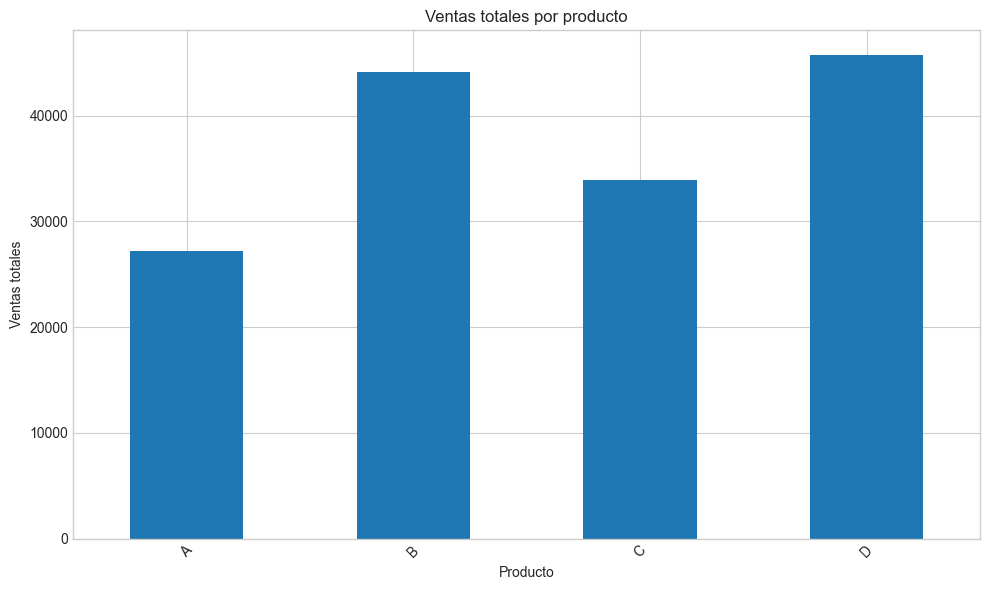

In [49]:
plt.figure(figsize=(10, 6))
ventas_por_producto.plot(kind='bar')
plt.title('Ventas totales por producto')
plt.xlabel('Producto')
plt.ylabel('Ventas totales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5.2 Gráfico de distribución de ventas

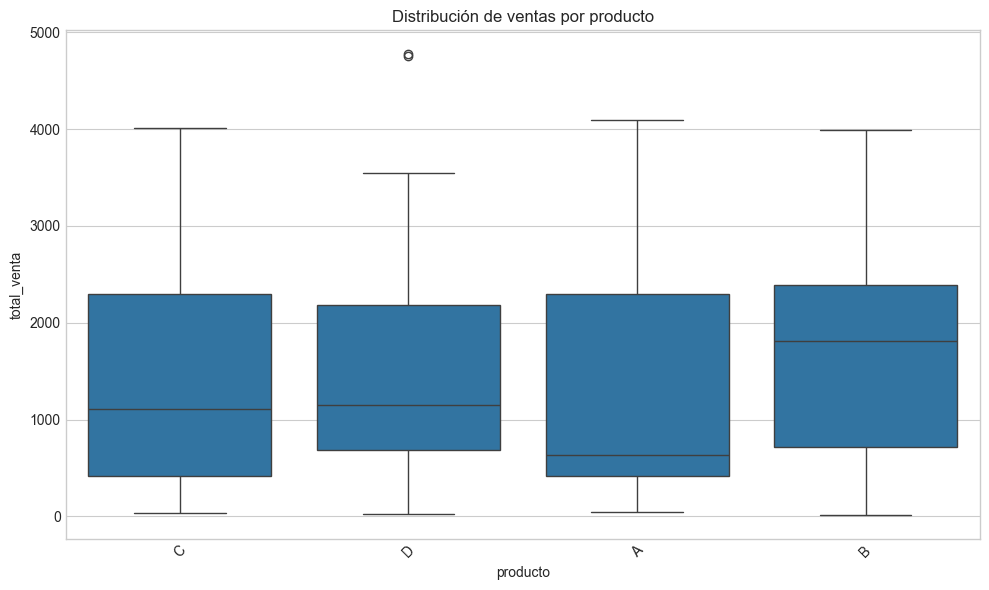

In [50]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='producto', y='total_venta', data=df_ventas)
plt.title('Distribución de ventas por producto')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5.3 Tendencia temporal de ventas

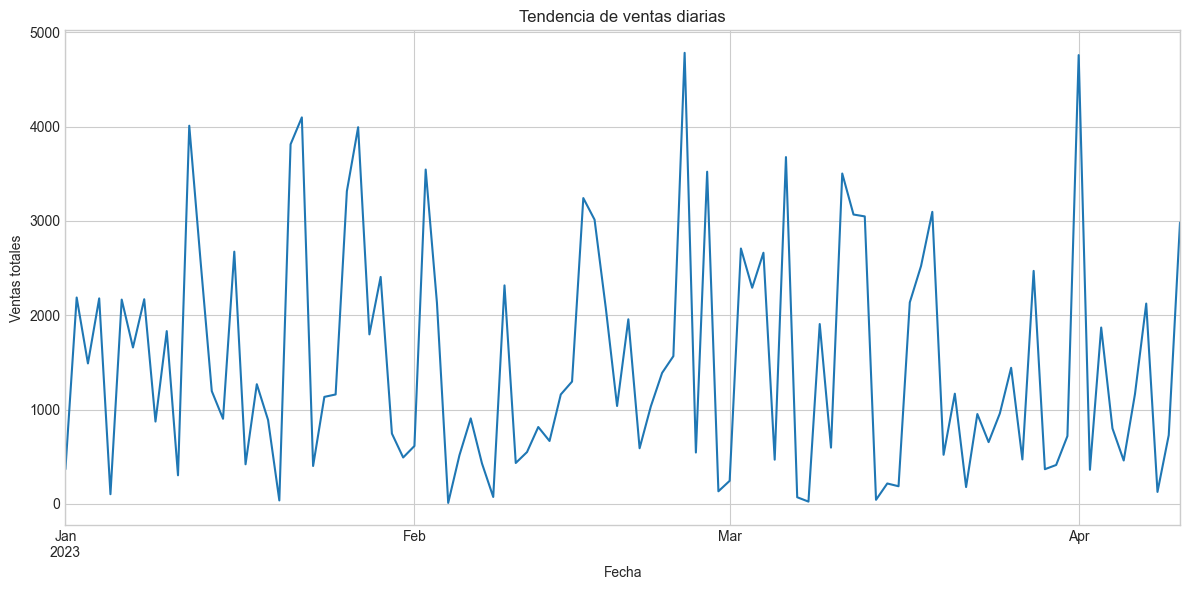

In [51]:
ventas_diarias = df_ventas.groupby('fecha')['total_venta'].sum()
plt.figure(figsize=(12, 6))
ventas_diarias.plot(kind='line')
plt.title('Tendencia de ventas diarias')
plt.xlabel('Fecha')
plt.ylabel('Ventas totales')
plt.tight_layout()
plt.show()

# 6. Ejercicios Prácticos

## Ejercicio 1: Análisis de Ventas
------------------------------
1. Encuentra el vendedor con más ventas totales
2. Calcula el promedio de ventas por día de la semana
3. Identifica el producto más vendido por región
4. Crea un gráfico que muestre la evolución de ventas por vendedor